# Pipeline B

This Notebook features the Dynamic Customer Segmentation implementation using the Pipeline B Dataset (Dataset of a United Kingdom Online business)

## Phase 1: Data Cleaning and Preprocessing 

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

print("--- PHASE 1: DATA CLEANING (ONLINE RETAIL) ---")

# 1. Load the Dataset
df_retail = pd.read_excel('Online UK_Retail.xlsx', engine='openpyxl')

# For the sake of testing without the file, we assume df_retail is already loaded here.
# (Keep your pd.read_excel line in your actual script)

# 2. Data Cleaning
# Drop rows without CustomerID
df_retail = df_retail.dropna(subset=['CustomerID'])

# Filter out cancellations (InvoiceNo starting with 'C')
df_retail = df_retail[~df_retail['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative quantities and prices
df_retail = df_retail[(df_retail['Quantity'] > 0) & (df_retail['UnitPrice'] > 0)]

# Calculate the actual transaction value
df_retail['Total_Price'] = df_retail['Quantity'] * df_retail['UnitPrice']

# Standardize Dates and strictly sort chronologically
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])
df_retail = df_retail.sort_values(by='InvoiceDate').reset_index(drop=True)

print(f"Dataset cleaned. Remaining records: {len(df_retail)}")


print("\n--- PHASE 2: DYNAMIC TIME SLICING (PREPARING THE CASCADE) ---")

def split_into_cycles(df, date_column='InvoiceDate', cycle_0_months=3):
    """
    Dynamically slices the dataset into Cycle 0 (baseline) and Cycles 1-n.
    Groups based on the actual chronological months present in the data.
    """
    # Create YearMonth period (e.g., '2010-12', '2011-01') for easy grouping
    df['YearMonth'] = df[date_column].dt.to_period('M')
    
    # Get a list of all unique months, perfectly sorted
    unique_months = sorted(df['YearMonth'].unique())
    
    # Identify the baseline months (the first 3 months: Dec, Jan, Feb)
    baseline_months = unique_months[:cycle_0_months]
    
    system_cycles = {}
    
    # --- Slice out Cycle 0 (Baseline) ---
    cycle_0_df = df[df['YearMonth'].isin(baseline_months)].copy()
    cycle_0_df = cycle_0_df.drop(columns=['YearMonth'])
    system_cycles['Cycle_0'] = cycle_0_df
    
    # --- Slice Cycles 1 through n (Dynamic Loop) ---
    remaining_months = unique_months[cycle_0_months:]
    
    cycle_num = 1
    for period in remaining_months:
        monthly_batch = df[df['YearMonth'] == period].copy()
        monthly_batch = monthly_batch.drop(columns=['YearMonth'])
        system_cycles[f'Cycle_{cycle_num}'] = monthly_batch
        cycle_num += 1
        
    return system_cycles

# Execute the dynamic split (We tell it to use 3 months for the baseline)
all_cycles = split_into_cycles(df_retail, date_column='InvoiceDate', cycle_0_months=3)

# Print a summary to verify it perfectly sliced your data
print("\n--- SLICING VERIFICATION ---")
for cycle_name, cycle_df in all_cycles.items():
    min_date = cycle_df['InvoiceDate'].min().strftime('%Y-%m-%d')
    max_date = cycle_df['InvoiceDate'].max().strftime('%Y-%m-%d')
    print(f"{cycle_name}: {len(cycle_df):,}\trecords  |  From: {min_date}  To: {max_date}")

--- PHASE 1: DATA CLEANING (ONLINE RETAIL) ---
Dataset cleaned. Remaining records: 397884

--- PHASE 2: DYNAMIC TIME SLICING (PREPARING THE CASCADE) ---

--- SLICING VERIFICATION ---
Cycle_0: 67,313	records  |  From: 2010-12-01  To: 2011-02-28
Cycle_1: 27,175	records  |  From: 2011-03-01  To: 2011-03-31
Cycle_2: 22,642	records  |  From: 2011-04-01  To: 2011-04-28
Cycle_3: 28,320	records  |  From: 2011-05-01  To: 2011-05-31
Cycle_4: 27,185	records  |  From: 2011-06-01  To: 2011-06-30
Cycle_5: 26,825	records  |  From: 2011-07-01  To: 2011-07-31
Cycle_6: 27,007	records  |  From: 2011-08-01  To: 2011-08-31
Cycle_7: 40,028	records  |  From: 2011-09-01  To: 2011-09-30
Cycle_8: 49,554	records  |  From: 2011-10-02  To: 2011-10-31
Cycle_9: 64,531	records  |  From: 2011-11-01  To: 2011-11-30
Cycle_10: 17,304	records  |  From: 2011-12-01  To: 2011-12-09


### Cascaded RFM Implementation

In [3]:
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

print("\n--- PHASE 3: CASCADED RFM (ONLINE RETAIL) ---")

def assign_recency_bin(days):
    """Isolates Recency into strict categorical risk brackets."""
    if days <= 30: return 1   # 'Best' (Active)
    elif days <= 60: return 2 # 'Loyal' (Recent)
    elif days <= 90: return 3 # 'Almost Lost' (Slipping)
    else: return 4            # 'Lost' (Inactive)

def apply_advanced_cascaded_rfm(cycles_dict):
    
    rfm_profiles = {}
    scaler = MinMaxScaler() # Initialize the scaler for distance math
    
    for cycle_name, df_cycle in cycles_dict.items():
        
        # --- SAFETY NET 1: Drop any duplicate columns inherited from raw Excel data ---
        df_cycle = df_cycle.loc[:, ~df_cycle.columns.duplicated()].copy()
        
        # Snapshot date: 1 day after the last transaction in THIS specific cycle
        snapshot_date = df_cycle['InvoiceDate'].max() + dt.timedelta(days=1)
        
        # 1. BASE CALCULATION (Adapted for UK Retail columns)
        rfm = df_cycle.groupby('CustomerID').agg(
            Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
            Frequency=('InvoiceNo', 'nunique'),     # Number of distinct shopping carts/orders
            Monetary=('Total_Price', 'sum')         # Total money spent in this cycle
        ).reset_index()
        
        # --- SAFETY NET 2: Ensure no duplicates accidentally survived the groupby ---
        rfm = rfm.loc[:, ~rfm.columns.duplicated()].copy()
        
        # 2. RECENCY ISOLATION
        rfm['Recency_Bucket'] = rfm['Recency'].apply(assign_recency_bin)
        
        # 3. STRUCTURAL PAIRING (Log Transformation)
        # Using np.log1p to safely handle any zeros (e.g., if Recency is 0 days)
        rfm['Log_R'] = np.log1p(rfm['Recency'])
        rfm['Log_F'] = np.log1p(rfm['Frequency'])
        rfm['Log_M'] = np.log1p(rfm['Monetary'])
        
        # Interaction features for the "Structural Pairs"
        rfm['RF_Score'] = rfm['Log_R'] * rfm['Log_F']
        rfm['RM_Score'] = rfm['Log_R'] * rfm['Log_M']
        rfm['FM_Score'] = rfm['Log_F'] * rfm['Log_M']
        
        # 4. MATHEMATICAL SCALING
        # We scale the core features so they don't overpower each other in Fuzzy C-Means
        features_to_scale = ['Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score']
        
        # Create scaled versions of these columns
        scaled_array = scaler.fit_transform(rfm[features_to_scale])
        scaled_df = pd.DataFrame(scaled_array, columns=[f"Scaled_{col}" for col in features_to_scale])
        
        # Join the scaled features back to the main RFM table
        rfm_final = pd.concat([rfm, scaled_df], axis=1)
        
        # Save to dictionary
        rfm_profiles[cycle_name] = rfm_final
        
    return rfm_profiles

# Execute the Advanced Cascaded RFM
rfm_cycles = apply_advanced_cascaded_rfm(all_cycles)

# --- VERIFICATION ---
print(f"Total Unique Customers in Cycle 0 (Baseline): {len(rfm_cycles['Cycle_0']):,}")
print("\nSample Cascaded RFM Features (Cycle 0):")
print(rfm_cycles['Cycle_0'][['CustomerID', 'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']].head())



--- PHASE 3: CASCADED RFM (ONLINE RETAIL) ---
Total Unique Customers in Cycle 0 (Baseline): 1,682

Sample Cascaded RFM Features (Cycle 0):
   CustomerID  Scaled_Log_R  Scaled_Log_F  Scaled_Log_M  Scaled_RF_Score  \
0     12346.0      0.803636      0.000000      1.000000         0.137042   
1     12347.0      0.749716      0.130227      0.607682         0.220744   
2     12348.0      0.757095      0.130227      0.602232         0.222739   
3     12350.0      0.691267      0.000000      0.488791         0.117880   
4     12352.0      0.509706      0.000000      0.477520         0.086919   

   Scaled_RM_Score  Scaled_FM_Score  
0         1.000000         0.230271  
1         0.570396         0.229575  
2         0.570187         0.227586  
3         0.425291         0.112555  
4         0.316429         0.109959  


--- VISUALIZING LOG TRANSFORMATION (PIPELINE B) ---


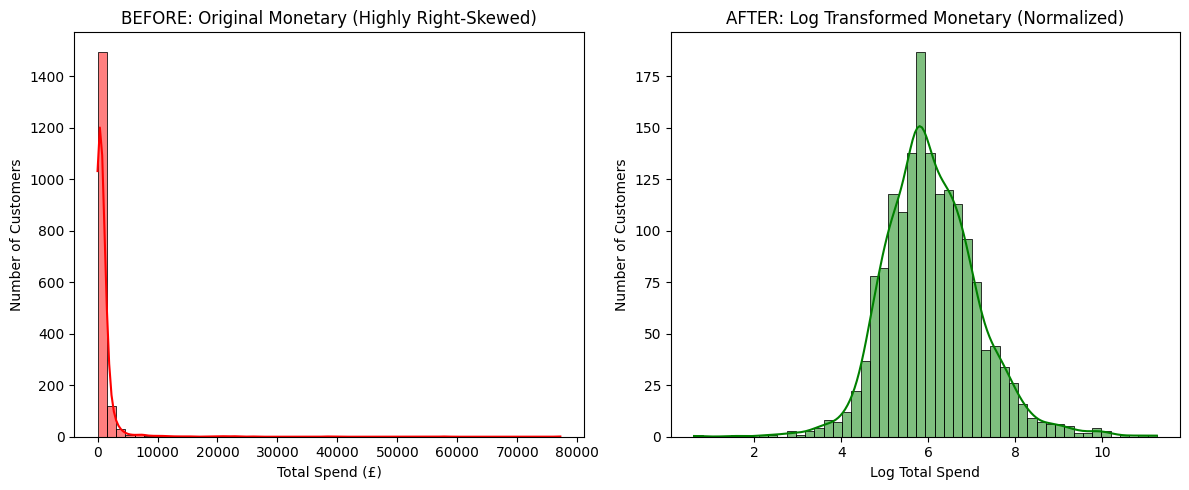

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALIZING LOG TRANSFORMATION (PIPELINE B) ---")

# We will look at the Baseline Cycle (Cycle 0) for the plot
baseline_rfm = rfm_cycles['Cycle_0']

# Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: BEFORE Log Transformation (Original Data)
sns.histplot(baseline_rfm['Monetary'], bins=50, ax=axes[0], color='red', kde=True)
axes[0].set_title('BEFORE: Original Monetary (Highly Right-Skewed)')
axes[0].set_xlabel('Total Spend (£)')
axes[0].set_ylabel('Number of Customers')

# Plot 2: AFTER Log Transformation
sns.histplot(baseline_rfm['Log_M'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('AFTER: Log Transformed Monetary (Normalized)')
axes[1].set_xlabel('Log Total Spend')
axes[1].set_ylabel('Number of Customers')

# Show the graphs
plt.tight_layout()
plt.show()

--- VISUALIZING THE FULL PREPROCESSING PIPELINE ---


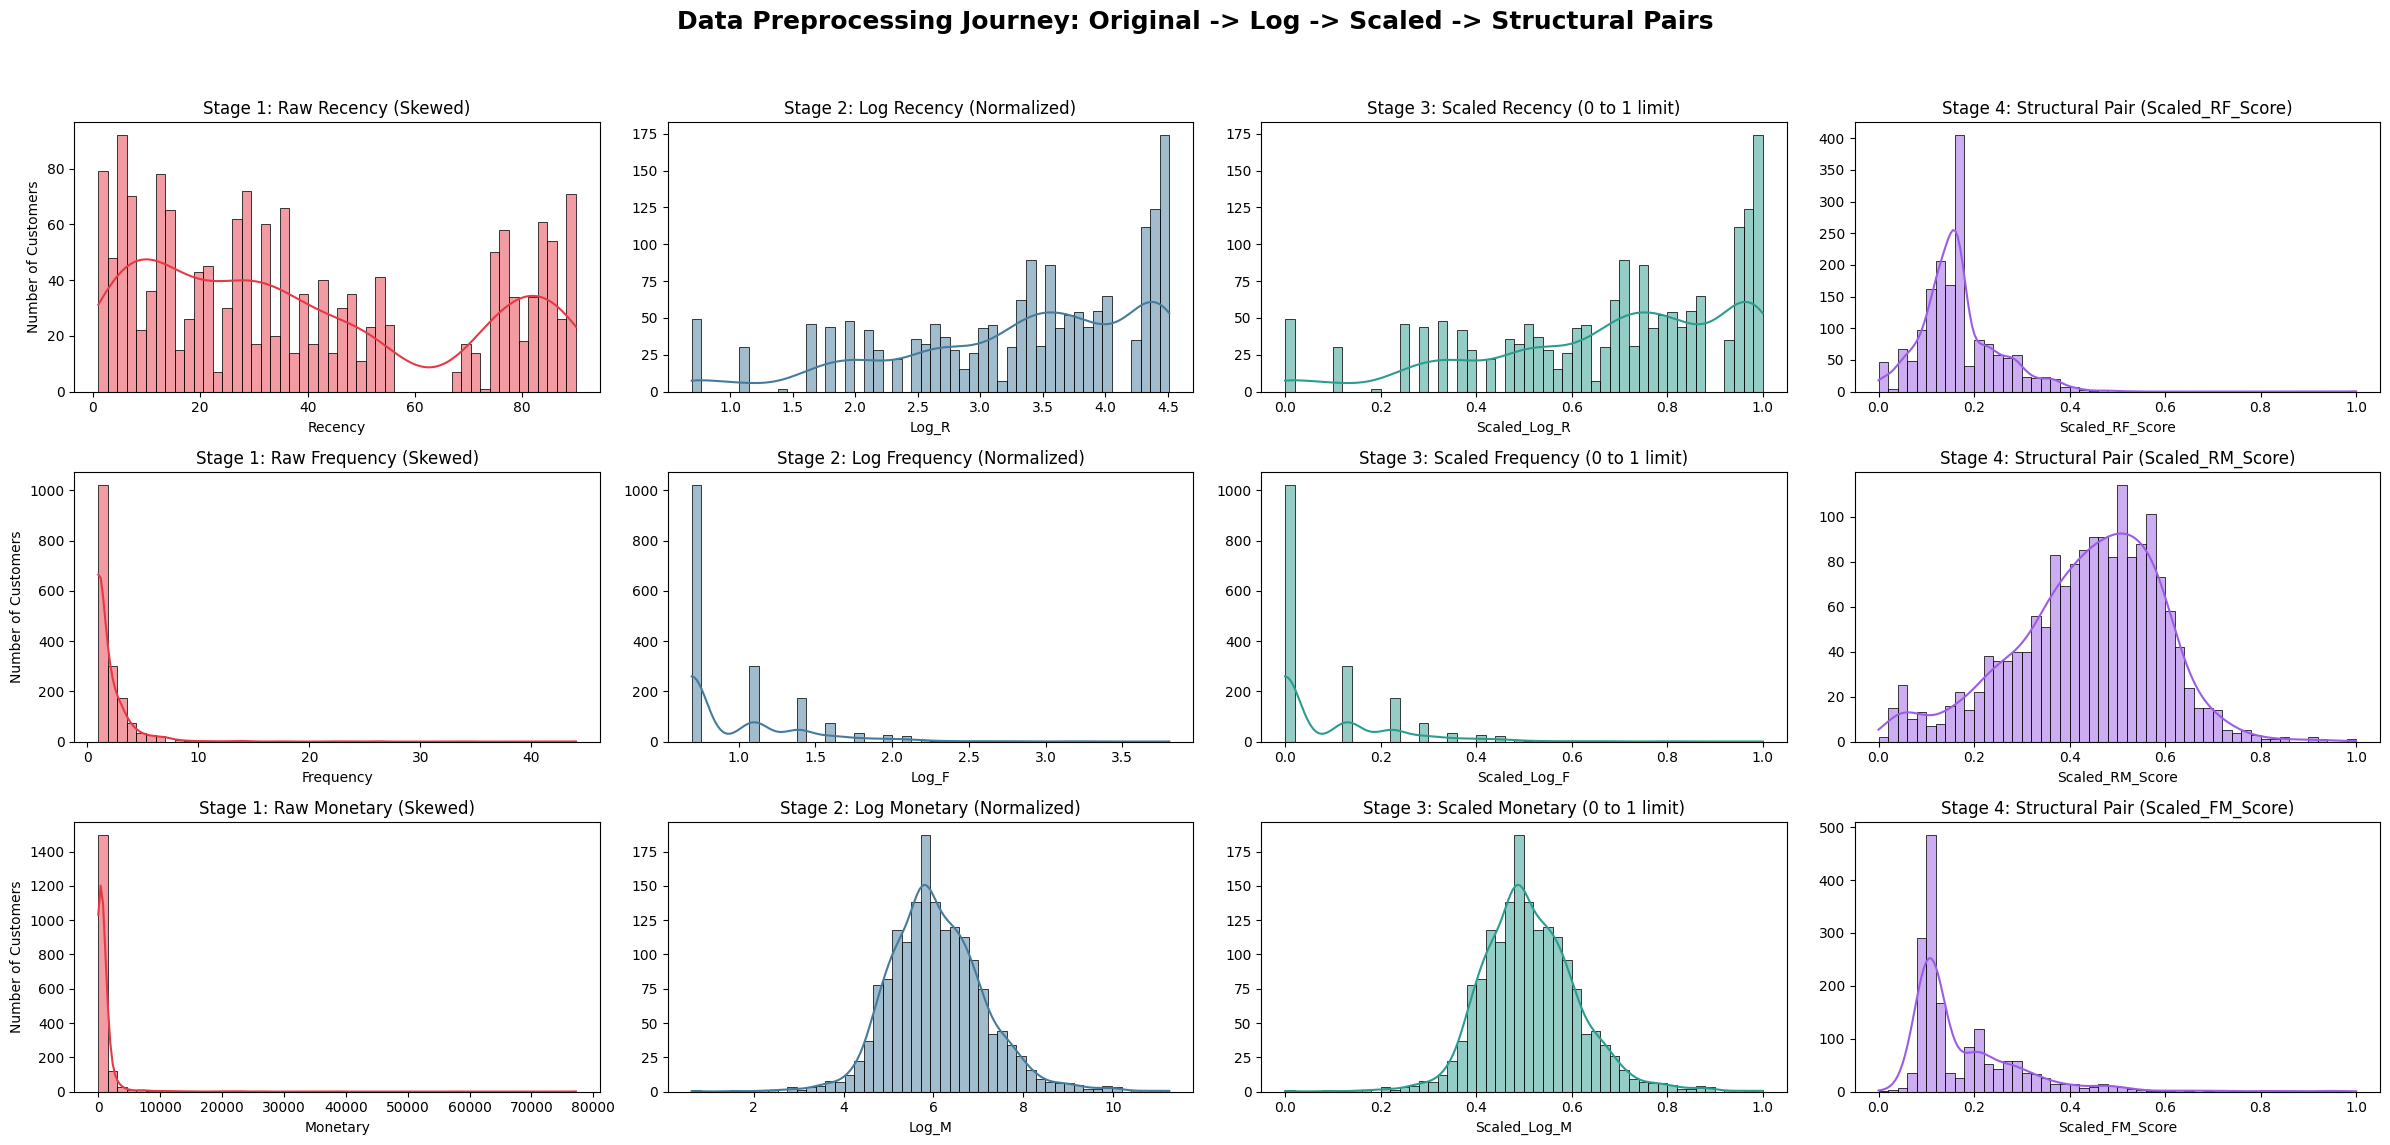

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALIZING THE FULL PREPROCESSING PIPELINE ---")

# We will use the Baseline Cycle (Cycle 0) for the plots
baseline_rfm = rfm_cycles['Cycle_0']

# Set up a 3x4 grid of plots (3 rows for R, F, M and 4 columns for the stages)
fig, axes = plt.subplots(3, 4, figsize=(24, 12))
fig.suptitle('Data Preprocessing Journey: Original -> Log -> Scaled -> Structural Pairs', fontsize=18, fontweight='bold')

# Feature lists to loop through
raw_features = ['Recency', 'Frequency', 'Monetary']
log_features = ['Log_R', 'Log_F', 'Log_M']
scaled_features = ['Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M']

# NEW: The Structural Interaction Pairs
pair_features = ['Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'] 

# Stage Colors: Red (Skewed), Blue (Normalizing), Green (Scaled), Purple (Structural Pairs)
colors = ['#e63946', '#457b9d', '#2a9d8f', '#9b5de5']

for i in range(3):
    # Column 1: BEFORE (Original Raw Data)
    sns.histplot(baseline_rfm[raw_features[i]], bins=50, ax=axes[i, 0], color=colors[0], kde=True)
    axes[i, 0].set_title(f'Stage 1: Raw {raw_features[i]} (Skewed)', fontsize=12)
    axes[i, 0].set_ylabel('Number of Customers')
    
    # Column 2: MIDDLE (Log Transformed)
    sns.histplot(baseline_rfm[log_features[i]], bins=50, ax=axes[i, 1], color=colors[1], kde=True)
    axes[i, 1].set_title(f'Stage 2: Log {raw_features[i]} (Normalized)', fontsize=12)
    axes[i, 1].set_ylabel('') # Hide y-label for middle to avoid clutter
    
    # Column 3: AFTER (MinMax Scaled Base Features)
    sns.histplot(baseline_rfm[scaled_features[i]], bins=50, ax=axes[i, 2], color=colors[2], kde=True)
    axes[i, 2].set_title(f'Stage 3: Scaled {raw_features[i]} (0 to 1 limit)', fontsize=12)
    axes[i, 2].set_ylabel('')
    
    # Column 4: FINAL (Structural Pairs / Cascaded Scores)
    sns.histplot(baseline_rfm[pair_features[i]], bins=50, ax=axes[i, 3], color=colors[3], kde=True)
    axes[i, 3].set_title(f'Stage 4: Structural Pair ({pair_features[i]})', fontsize=12)
    axes[i, 3].set_ylabel('')

# Adjust layout so titles don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Creation of sql tables and database

In [20]:
import sqlite3
import pandas as pd
import json

print("--- PHASE 4: DATABASE CREATION (PIPELINE B) ---")

# 1. Initialize and connect to the Pipeline B SQLite Database
conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# Enable foreign keys for relational integrity
cursor.execute("PRAGMA foreign_keys = ON;")

# Step 1: Customer Table (Firmographic Segmentation ONLY)
# Stores unique customer profiles based on Business Location (Country)
cursor.execute('''
CREATE TABLE IF NOT EXISTS Customer (
    CustomerID TEXT PRIMARY KEY,
    Country TEXT
)
''')

# Step 2: Data Preprocessing Results Table
# Added Cycle_End_Date to accurately track the dynamic temporal slices
cursor.execute('''
CREATE TABLE IF NOT EXISTS Data_Preprocessing_Results (
    PreprocessID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    CycleID TEXT,
    Cycle_End_Date TEXT,  -- NEW: Snapshot date for the cycle's RFM calculation
    Recency INTEGER,
    Frequency INTEGER,
    Monetary REAL,
    Recency_Bucket INTEGER,
    Log_R REAL,
    Log_F REAL,
    Log_M REAL,
    RF_Score REAL,
    RM_Score REAL,
    FM_Score REAL,
    Scaled_Log_R REAL,
    Scaled_Log_F REAL,
    Scaled_Log_M REAL,
    Scaled_RF_Score REAL,
    Scaled_RM_Score REAL,
    Scaled_FM_Score REAL,
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

# Step 3: Time Cycle 0 Segmentation Table 
# Added Optimal K, Elbow Inertia, and Silhouette Score
cursor.execute('''
CREATE TABLE IF NOT EXISTS Time_Cycle_0_Segmentation (
    Cycle0_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    Optimal_K_Value INTEGER,       -- NEW: The optimal number of clusters chosen (e.g., 4)
    Elbow_Inertia_Value REAL,      -- NEW: The WCSS value at the elbow point
    Silhouette_Score REAL,         -- NEW: Model validation score for Cycle 0
    KMeans_Cluster_Number INTEGER, -- The specific cluster assigned to this customer (1 to K)
    Baseline_Segment_Name TEXT,
    Initial_Centroids TEXT,        -- Stored as JSON string
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

# Step 4: Dynamic Loop Results Table 
# Added Previous_Cluster and All_Fuzzy_Memberships for realistic MDFCM tracking
cursor.execute('''
CREATE TABLE IF NOT EXISTS Dynamic_Loop_Results (
    DynamicID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    CycleID TEXT,
    Previous_Cluster INTEGER,        -- NEW: Tracked from t-1 to determine migration
    MDFCM_Cluster_Number INTEGER,    
    Highest_Membership_Score REAL,   -- The winning fuzzy probability
    All_Fuzzy_Memberships TEXT,      -- NEW: JSON array of probabilities for ALL clusters
    Migration_Status TEXT,           -- e.g., 'Retained', 'Migrated Up', 'Migrated Down'
    Segment_Name TEXT,
    Updated_Centroids TEXT,          -- Stored as JSON string
    Dynamic_Silhouette_Score REAL,   -- NEW: Validation score for the current cycle
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

# Commit the table structures to the database
conn.commit()

print("Pipeline B Database and Relational Tables successfully created.")
print("Tables ready: Customer, Data_Preprocessing_Results, Time_Cycle_0_Segmentation, Dynamic_Loop_Results.")

--- PHASE 4: DATABASE CREATION (PIPELINE B) ---
Pipeline B Database and Relational Tables successfully created.
Tables ready: Customer, Data_Preprocessing_Results, Time_Cycle_0_Segmentation, Dynamic_Loop_Results.


## Population of database 

In [21]:
import sqlite3
import pandas as pd

print("--- PHASE 4B: POPULATING BASE TABLES BEFORE K-MEANS ---")

# Connect to the Pipeline B database
conn = sqlite3.connect('csrs_pipeline_b.db')

# 1. Populate the 'Customer' Table (Firmographic Data)
# Extract unique CustomerIDs and their associated Country from the raw dataframe
firmographic_df = df_retail[['CustomerID', 'Country']].drop_duplicates(subset=['CustomerID']).copy()

# CLEANING STEP: CustomerIDs in the dataframe are currently floats (e.g., 12346.0). 
# We must convert them to integers and then strings to match our TEXT Primary Key schema cleanly.
firmographic_df['CustomerID'] = firmographic_df['CustomerID'].astype(int).astype(str)

try:
    firmographic_df.to_sql('Customer', conn, if_exists='append', index=False)
    print(f"Successfully inserted {len(firmographic_df)} unique B2B firmographic profiles into the 'Customer' table.")
except sqlite3.IntegrityError:
    print("Customer table already populated.")


# 2. Populate 'Data_Preprocessing_Results' Table
# We loop through the rfm_cycles dictionary generated in Phase 3
records_inserted = 0

for cycle_name, rfm_df in rfm_cycles.items():
    # Make a copy to avoid modifying the original dataframe
    insert_df = rfm_df.copy()
    
    # Add the CycleID column (e.g., 'Cycle_0', 'Cycle_1')
    insert_df['CycleID'] = cycle_name
    
    # Dynamically extract the Snapshot Date (Cycle_End_Date) from the corresponding all_cycles slice
    # This matches the max date + 1 day logic you used during preprocessing
    cycle_end_date = all_cycles[cycle_name]['InvoiceDate'].max() + pd.Timedelta(days=1)
    insert_df['Cycle_End_Date'] = cycle_end_date.strftime('%Y-%m-%d')
    
    # Ensure CustomerID is formatted as a clean string for accurate Foreign Key mapping
    insert_df['CustomerID'] = insert_df['CustomerID'].astype(int).astype(str)
    
    # Filter only the columns that match our SQLite schema perfectly
    cols_to_insert = [
        'CustomerID', 'CycleID', 'Cycle_End_Date', 'Recency', 'Frequency', 'Monetary', 
        'Recency_Bucket', 'Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score', 
        'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'
    ]
    insert_df = insert_df[cols_to_insert]
    
    # Insert into the database
    insert_df.to_sql('Data_Preprocessing_Results', conn, if_exists='append', index=False)
    records_inserted += len(insert_df)

print(f"Successfully inserted {records_inserted} preprocessed RFM records across all cycles into 'Data_Preprocessing_Results'.")
print("Database is now primed. You can proceed with Time Cycle 0 Baseline K-Means.")

# Commit and safely close the connection
conn.commit()
conn.close()

--- PHASE 4B: POPULATING BASE TABLES BEFORE K-MEANS ---
Successfully inserted 4338 unique B2B firmographic profiles into the 'Customer' table.
Successfully inserted 12352 preprocessed RFM records across all cycles into 'Data_Preprocessing_Results'.
Database is now primed. You can proceed with Time Cycle 0 Baseline K-Means.


In [27]:
import sqlite3

print("--- UPGRADING DATABASE SCHEMA FOR VISUALIZATIONS ---")

conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# 1. Drop the old table so we can rebuild it with the new Visual fields
cursor.execute("DROP TABLE IF EXISTS Time_Cycle_0_Segmentation")

# 2. Recreate the table WITH the new PC1, PC2, and PC3 visual fields included
cursor.execute('''
CREATE TABLE Time_Cycle_0_Segmentation (
    Cycle0_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    Optimal_K_Value INTEGER,       
    Elbow_Inertia_Value REAL,      
    Silhouette_Score REAL,         
    KMeans_Cluster_Number INTEGER, 
    Baseline_Segment_Name TEXT,
    Initial_Centroids TEXT,        
    PC1 REAL,  -- NEW: X-Axis coordinate for 2D/3D visual dashboards
    PC2 REAL,  -- NEW: Y-Axis coordinate for 2D/3D visual dashboards
    PC3 REAL,  -- NEW: Z-Axis coordinate for 3D visual dashboards
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

conn.commit()
conn.close()
print("Time_Cycle_0_Segmentation table upgraded successfully with PC1, PC2, and PC3 fields!")

--- UPGRADING DATABASE SCHEMA FOR VISUALIZATIONS ---
Time_Cycle_0_Segmentation table upgraded successfully with PC1, PC2, and PC3 fields!


## Initial K-Means

--- PHASE 5: BASELINE K-MEANS SEGMENTATION (TIME CYCLE 0) ---
Loaded 1682 records for Cycle 0 Baseline Segmentation.
Calculating optimal K using Elbow Method and Silhouette Analysis on Cascaded Features...


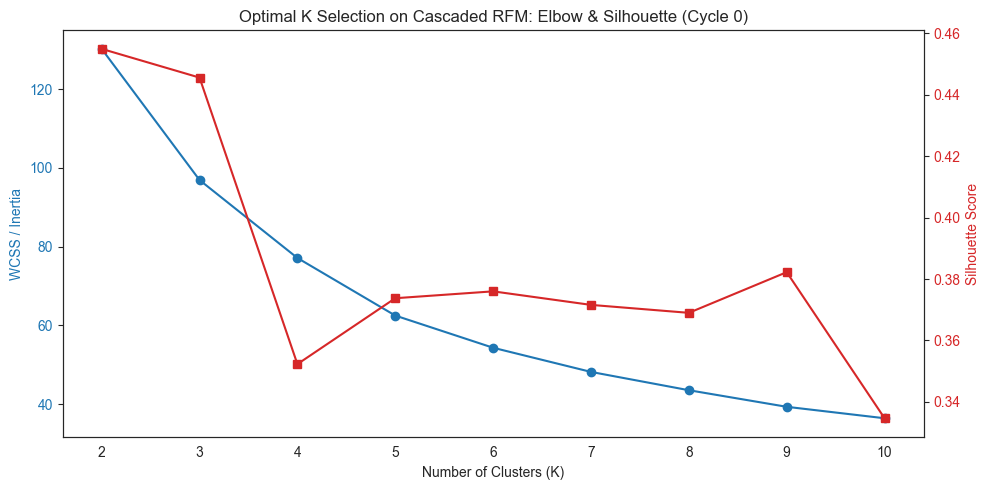


---> Selected K Value: 4
Metrics for K=4 -> WCSS: 77.12 | Silhouette: 0.3523

--- Complete 6D + Raw Cluster Profiling (Medians) ---
KMeans_Cluster_Number           0           1           2            3
Recency                 76.000000    5.000000   27.000000    16.000000
Frequency                1.000000    1.000000    1.000000     4.000000
Monetary               312.950000  462.475000  307.925000  1372.900000
Scaled_Log_R             0.956242    0.287767    0.691267     0.560562
Scaled_Log_F             0.000000    0.000000    0.000000     0.294295
Scaled_Log_M             0.482579    0.519192    0.481062     0.621333
Scaled_RF_Score          0.166952    0.061922    0.125219     0.269856
Scaled_RM_Score          0.554711    0.204200    0.400797     0.458820
Scaled_FM_Score          0.112426    0.132183    0.112010     0.334660

Successfully stored 1682 complete 6D baseline profiles into the database.
Phase 5 Complete.


In [22]:
import sqlite3
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("--- PHASE 5: BASELINE K-MEANS SEGMENTATION (TIME CYCLE 0) ---")

# 1. Connect to Database and Fetch Cycle 0 Data
conn = sqlite3.connect('csrs_pipeline_b.db')

# Fetching the scaled RFM features AND Cascaded Features required for clustering
query = """
    SELECT CustomerID, 
           Scaled_Log_R, Scaled_Log_F, Scaled_Log_M, 
           Scaled_RF_Score, Scaled_RM_Score, Scaled_FM_Score,
           Recency, Frequency, Monetary
    FROM Data_Preprocessing_Results
    WHERE CycleID = 'Cycle_0'
"""
df_cycle0 = pd.read_sql_query(query, conn)

print(f"Loaded {len(df_cycle0)} records for Cycle 0 Baseline Segmentation.")

# Set up all 6 features for clustering (Cascaded RFM)
X_cycle0 = df_cycle0[[
    'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M',
    'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'
]].values

# 2. Determine Optimal K (Elbow Method & Silhouette Score)
wcss = []
silhouette_scores = []
K_range = range(2, 11) # Testing K from 2 to 10

print("Calculating optimal K using Elbow Method and Silhouette Analysis on Cascaded Features...")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_cycle0)
    
    wcss.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_cycle0, labels))

# Plotting the evaluation metrics for visualization
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot WCSS (Elbow)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS / Inertia', color='tab:blue')
ax1.plot(K_range, wcss, marker='o', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette Score
ax2 = ax1.twinx()  
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K Selection on Cascaded RFM: Elbow & Silhouette (Cycle 0)')
fig.tight_layout()
plt.show()

# --- OPTIMAL K SELECTION GUIDE ---

# the cleanest business logic differentiation. We default to 4 based on the WCSS inflection point.
optimal_k = 4
optimal_k_index = K_range.index(optimal_k)
optimal_wcss = wcss[optimal_k_index]
optimal_silhouette = silhouette_scores[optimal_k_index]

print(f"\n---> Selected K Value: {optimal_k}")
print(f"Metrics for K={optimal_k} -> WCSS: {optimal_wcss:.2f} | Silhouette: {optimal_silhouette:.4f}")

# 3. Execute Baseline K-Means with Optimal K
kmeans_baseline = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_cycle0['KMeans_Cluster_Number'] = kmeans_baseline.fit_predict(X_cycle0)

# Extract 6-dimensional centroids and convert to a JSON string for DB storage
centroids = kmeans_baseline.cluster_centers_
centroids_json = json.dumps(centroids.tolist())

# 4. Profile the Segments (UPDATED: SHOWING THE FULL 6D FEATURES + RAW VALUE MEDIANS)
features_to_profile = [
    'Recency', 'Frequency', 'Monetary',                  # Raw values for business context
    'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M',      # Core model features
    'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score' # Cascaded interaction features
]

# Calculate the median across all 9 dimensions
cluster_profiles = df_cycle0.groupby('KMeans_Cluster_Number')[features_to_profile].median()

# Assigning generic names based on cluster number
segment_names = {i: f"Baseline Segment {i}" for i in range(optimal_k)}
df_cycle0['Baseline_Segment_Name'] = df_cycle0['KMeans_Cluster_Number'].map(segment_names)

print("\n--- Complete 6D + Raw Cluster Profiling (Medians) ---")
# Transposing (.T) makes it much easier to compare features side-by-side vertically
print(cluster_profiles.T)

# 5. Prepare and Save Results to Time_Cycle_0_Segmentation Table
insert_df = df_cycle0[['CustomerID', 'KMeans_Cluster_Number', 'Baseline_Segment_Name']].copy()

# Add the model metadata columns universaly
insert_df['Optimal_K_Value'] = int(optimal_k)
insert_df['Elbow_Inertia_Value'] = float(optimal_wcss)
insert_df['Silhouette_Score'] = float(optimal_silhouette)
insert_df['Initial_Centroids'] = centroids_json

cols_to_insert = [
    'CustomerID', 'Optimal_K_Value', 'Elbow_Inertia_Value', 
    'Silhouette_Score', 'KMeans_Cluster_Number', 
    'Baseline_Segment_Name', 'Initial_Centroids'
]
insert_df = insert_df[cols_to_insert]

# Insert into the database
try:
    cursor = conn.cursor()
    cursor.execute("DELETE FROM Time_Cycle_0_Segmentation")
    conn.commit()
    
    insert_df.to_sql('Time_Cycle_0_Segmentation', conn, if_exists='append', index=False)
    print(f"\nSuccessfully stored {len(insert_df)} complete 6D baseline profiles into the database.")
    
except Exception as e:
    print(f"Database insertion failed: {e}")

# Close the connection
conn.close()
print("Phase 5 Complete.")

In [28]:
import sqlite3
import pandas as pd
import numpy as np
import json
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

print("--- PHASE 5: PCA CLUSTERING, RAW PROFILING & SAVING VISUALS TO DB ---")

# 1. Fetch Cycle 0 Data
conn = sqlite3.connect('csrs_pipeline_b.db')
query = """
    SELECT CustomerID, 
           Recency, Frequency, Monetary,
           Scaled_Log_R, Scaled_Log_F, Scaled_Log_M, 
           Scaled_RF_Score, Scaled_RM_Score, Scaled_FM_Score
    FROM Data_Preprocessing_Results
    WHERE CycleID = 'Cycle_0'
"""
df_cycle0 = pd.read_sql_query(query, conn)

# 2. PCA Compression (6D -> 3D)
scaled_cols = [
    'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M',
    'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'
]
X_scaled = df_cycle0[scaled_cols].values

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Append the visual coordinates to our dataframe so they can be saved
df_cycle0['PC1'] = X_pca[:, 0]
df_cycle0['PC2'] = X_pca[:, 1]
df_cycle0['PC3'] = X_pca[:, 2]

# 3. K-Means Clustering on the 3 PCA components
optimal_k = 4  
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_cycle0['KMeans_Cluster_Number'] = kmeans.fit_predict(X_pca)

# Extract 3D PCA Centroids for Phase 6 dynamic tracking
pca_centroids = kmeans.cluster_centers_
centroids_json = json.dumps(pca_centroids.tolist())

# 4. Raw Business Profiling ("Golden Rule")
df_cycle0['Raw_RF'] = df_cycle0['Recency'] * df_cycle0['Frequency']
df_cycle0['Raw_RM'] = df_cycle0['Recency'] * df_cycle0['Monetary']
df_cycle0['Raw_FM'] = df_cycle0['Frequency'] * df_cycle0['Monetary']

raw_business_cols = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
cluster_averages = df_cycle0.groupby('KMeans_Cluster_Number')[raw_business_cols].mean()
cluster_sizes = df_cycle0.groupby('KMeans_Cluster_Number').size().rename('Customer_Count')
cluster_summary = cluster_averages.join(cluster_sizes)

print("\n--- FINAL RAW BUSINESS PROFILES BY CLUSTER (AVERAGES) ---")
print(cluster_summary.T.round(2).to_string())

# Apply segment names based on the raw profiles
segment_names = {
    0: "Champions", 
    1: "New Loyalists", 
    2: "Hibernating High-Value", 
    3: "Mid-Tier Occasionals"
}
df_cycle0['Baseline_Segment_Name'] = df_cycle0['KMeans_Cluster_Number'].map(segment_names)

# 5. Save EVERYTHING to Database (Including Visual Fields)
insert_df = df_cycle0[[
    'CustomerID', 'KMeans_Cluster_Number', 'Baseline_Segment_Name',
    'PC1', 'PC2', 'PC3'  # Injecting the visual coordinates here
]].copy()

# Add Metadata
insert_df['Optimal_K_Value'] = int(optimal_k)
insert_df['Elbow_Inertia_Value'] = float(kmeans.inertia_)
insert_df['Silhouette_Score'] = -1.0 
insert_df['Initial_Centroids'] = centroids_json

cols_to_insert = [
    'CustomerID', 'Optimal_K_Value', 'Elbow_Inertia_Value', 
    'Silhouette_Score', 'KMeans_Cluster_Number', 
    'Baseline_Segment_Name', 'Initial_Centroids',
    'PC1', 'PC2', 'PC3'
]
insert_df = insert_df[cols_to_insert]

try:
    cursor = conn.cursor()
    cursor.execute("DELETE FROM Time_Cycle_0_Segmentation") # Clear old records safely
    conn.commit()
    
    insert_df.to_sql('Time_Cycle_0_Segmentation', conn, if_exists='append', index=False)
    print(f"\nSUCCESS: Saved {len(insert_df)} profiles AND their PCA Visual Coordinates to the database.")
except Exception as e:
    print(f"\nDatabase insertion failed: {e}")

conn.close()
print("Phase 5 Complete. Time Cycle 0 is locked in.")

--- PHASE 5: PCA CLUSTERING, RAW PROFILING & SAVING VISUALS TO DB ---

--- FINAL RAW BUSINESS PROFILES BY CLUSTER (AVERAGES) ---
KMeans_Cluster_Number         0        1         2        3
Recency                   19.46     4.63     69.27    25.87
Frequency                  5.26     2.03      1.29     1.27
Monetary                2991.12   705.83    648.98   394.72
Raw_RF                    94.07     8.20     86.78    31.92
Raw_RM                 48347.26  2943.37  37512.48  9310.43
Raw_FM                 24389.17  2489.10    944.05   551.20
Customer_Count           259.00   258.00    679.00   486.00

SUCCESS: Saved 1682 profiles AND their PCA Visual Coordinates to the database.
Phase 5 Complete. Time Cycle 0 is locked in.


In [33]:
import sqlite3

print("--- FIXING CYCLE 0 SEGMENT LABELS ---")

conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# The mathematically correct mapping based on the diagnostic data
correct_mapping = {
    2: 'Champions',
    0: 'Core Loyalists',
    1: 'Mid-Tier Occasionals',
    3: 'Hibernating / Lost'
}

try:
    for cluster_id, correct_name in correct_mapping.items():
        cursor.execute("""
            UPDATE Time_Cycle_0_Segmentation
            SET Baseline_Segment_Name = ?
            WHERE KMeans_Cluster_Number = ?
        """, (correct_name, cluster_id))
        
    conn.commit()
    print("SUCCESS: All customer segment names have been corrected in the database.")
    
except Exception as e:
    print(f"Failed to update database: {e}")

finally:
    conn.close()

--- FIXING CYCLE 0 SEGMENT LABELS ---
SUCCESS: All customer segment names have been corrected in the database.


visualazion


--- PHASE 5C: 3D PRESENTATION-READY VISUALIZATIONS ---
Loaded 1682 records with 3D PCA coordinates.


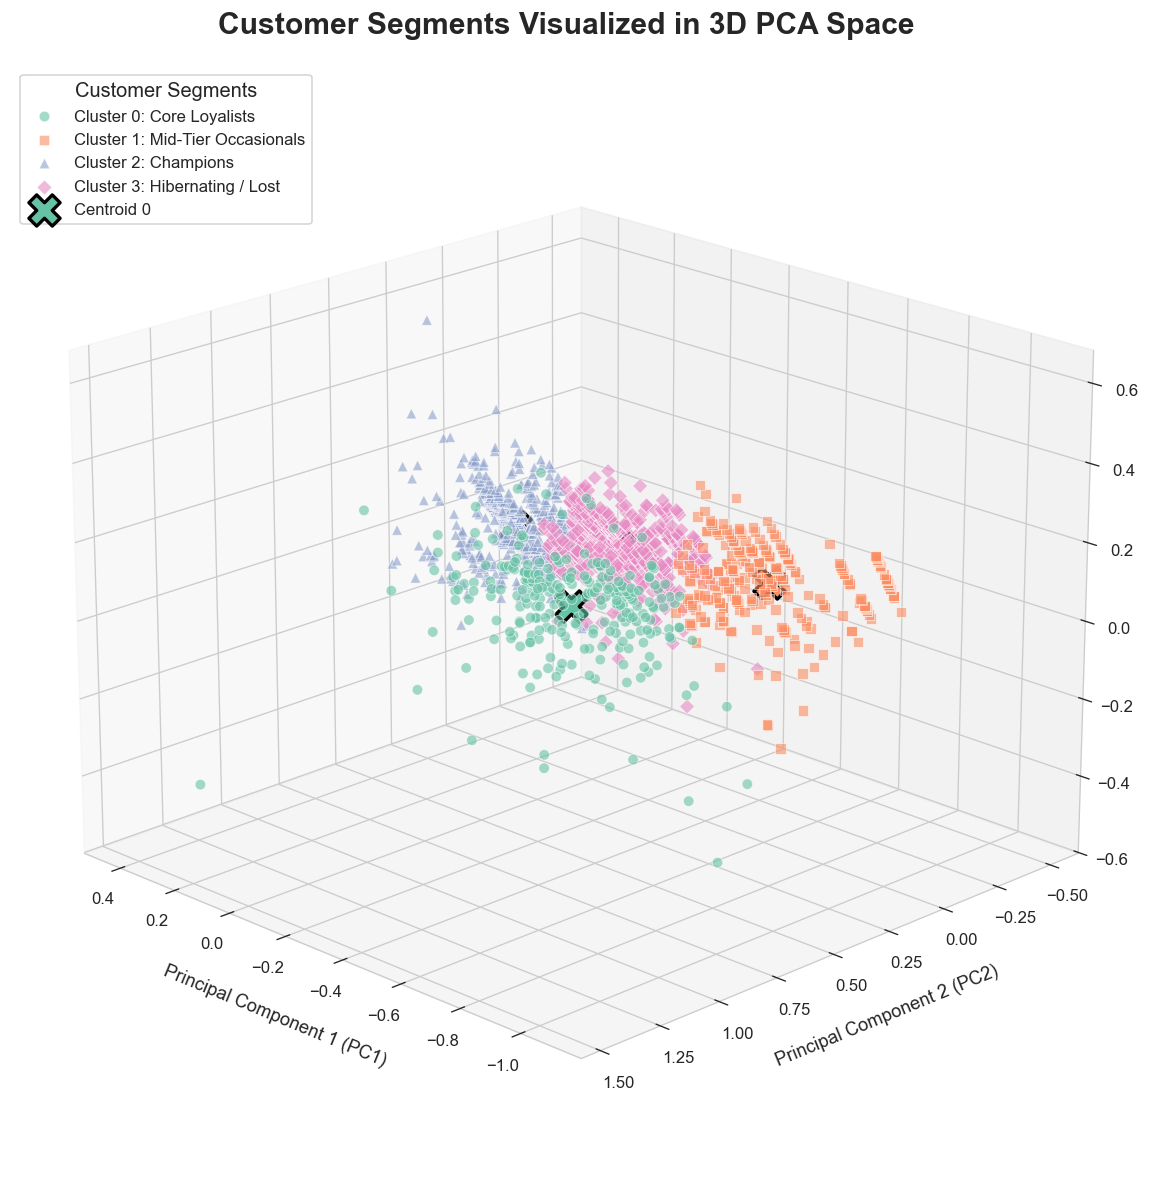

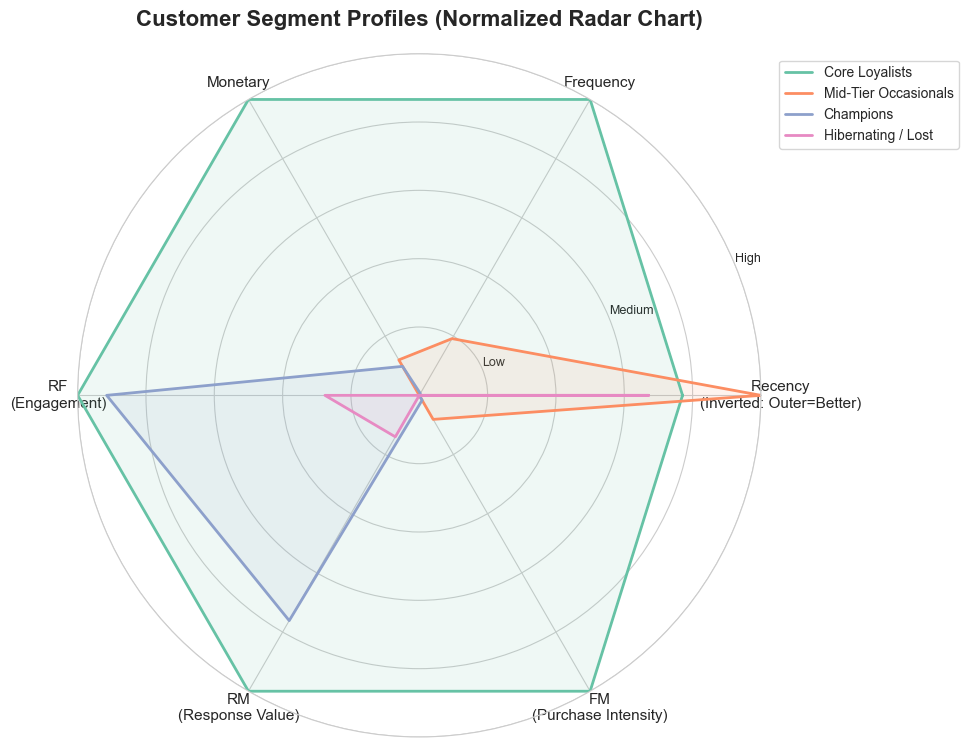

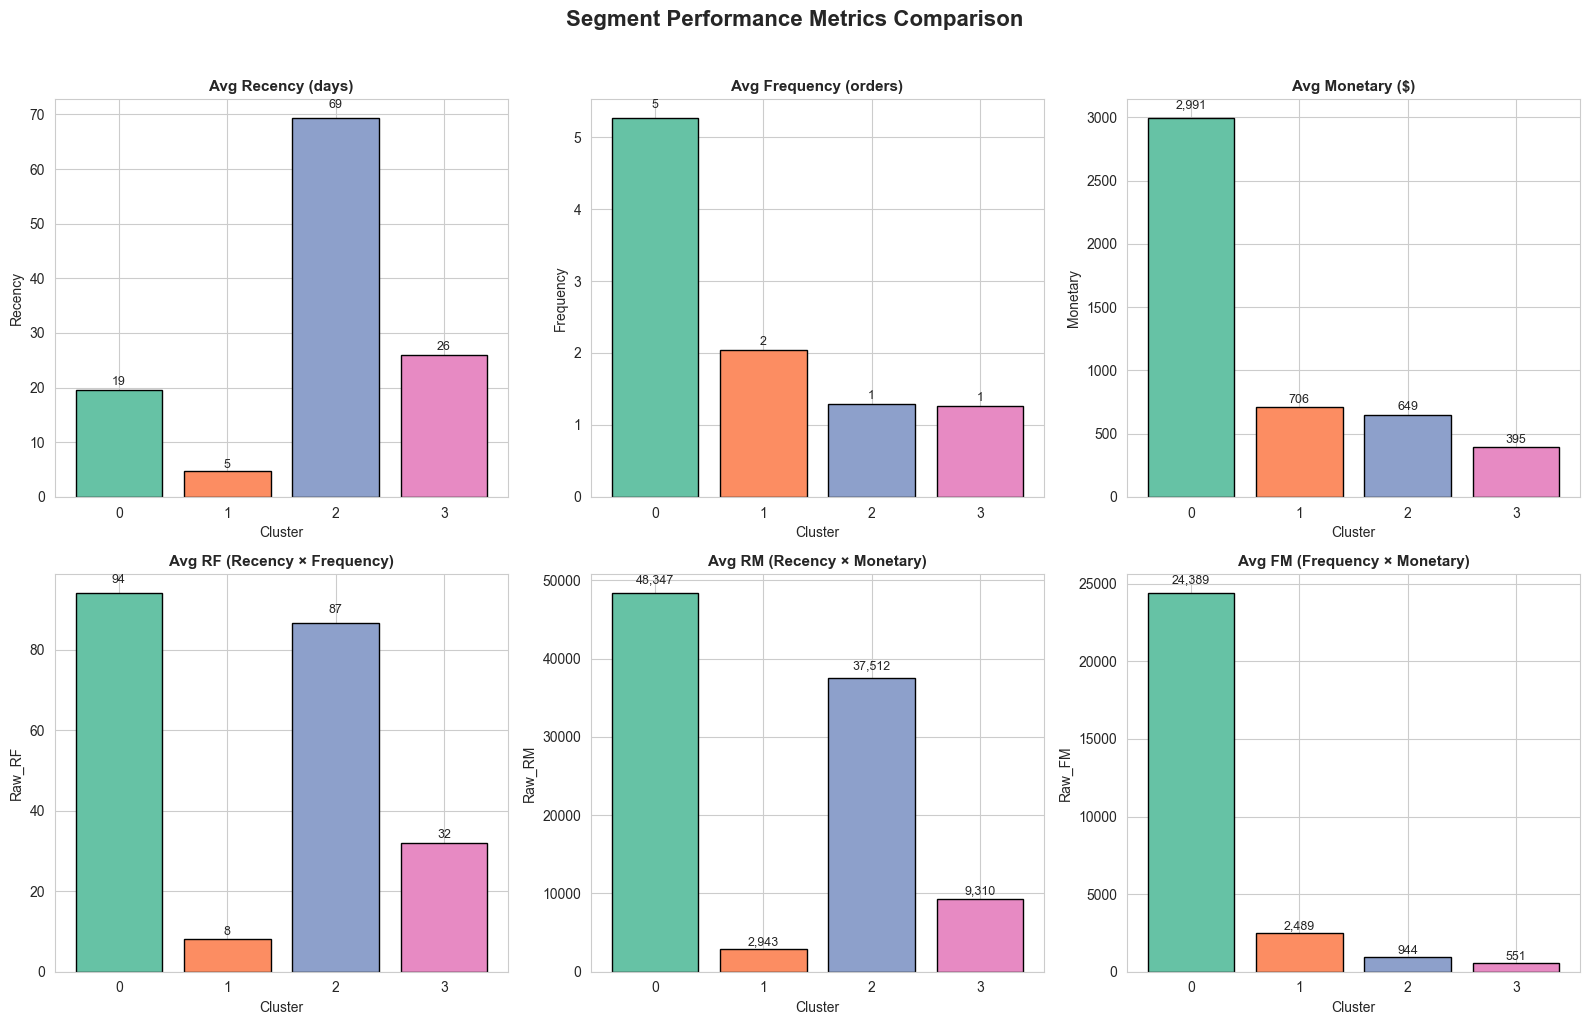


--- ALL VISUALIZATIONS SAVED AS HIGH-RES PNG FILES ---
1. pca_3d_cluster_visualization.png
2. radar_chart_segments.png
3. segment_metrics_barchart.png


In [34]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

print("--- PHASE 5C: 3D PRESENTATION-READY VISUALIZATIONS ---")

# 1. Fetch the clustered data WITH the saved 3D PCA components
conn = sqlite3.connect('csrs_pipeline_b.db')

# Notice we are pulling PC1, PC2, and PC3 directly from the database now!
query = """
    SELECT dp.CustomerID, 
           dp.Recency, dp.Frequency, dp.Monetary,
           ts.KMeans_Cluster_Number, ts.Baseline_Segment_Name,
           ts.PC1, ts.PC2, ts.PC3
    FROM Data_Preprocessing_Results dp
    JOIN Time_Cycle_0_Segmentation ts ON dp.CustomerID = ts.CustomerID
    WHERE dp.CycleID = 'Cycle_0'
"""
df_vis = pd.read_sql_query(query, conn)
conn.close()

if df_vis.empty:
    print("Error: No data found. Ensure Phase 5 was run and saved PC1, PC2, PC3.")
else:
    print(f"Loaded {len(df_vis)} records with 3D PCA coordinates.")

    # 1b. Calculate Raw Interaction Terms for Profiling Charts
    df_vis['Raw_RF'] = df_vis['Recency'] * df_vis['Frequency']
    df_vis['Raw_RM'] = df_vis['Recency'] * df_vis['Monetary']
    df_vis['Raw_FM'] = df_vis['Frequency'] * df_vis['Monetary']

    # Set up global styling and mappings
    marker_map = {0: 'o', 1: 's', 2: '^', 3: 'D'}  
    color_palette = sns.color_palette("Set2", n_colors=4).as_hex()

    # Dynamic names pulled directly from your database
    cluster_names = {
        k: v for k, v in zip(df_vis['KMeans_Cluster_Number'], df_vis['Baseline_Segment_Name'])
    }

    # ============================================================
    # VISUALIZATION 1: 3D SCATTER PLOT (PCA COMPONENTS 1, 2, & 3)
    # ============================================================
    fig = plt.figure(figsize=(14, 10), dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    sns.set_style("whitegrid")

    for cluster_id in sorted(df_vis['KMeans_Cluster_Number'].unique()):
        cluster_data = df_vis[df_vis['KMeans_Cluster_Number'] == cluster_id]
        
        ax.scatter(
            cluster_data['PC1'],
            cluster_data['PC2'],
            cluster_data['PC3'],
            label=f"Cluster {cluster_id}: {cluster_names[cluster_id]}",
            alpha=0.6,
            s=40,
            marker=marker_map[cluster_id],
            color=color_palette[cluster_id],
            edgecolors='white',
            linewidth=0.5
        )

    # Add 3D centroids
    centroids = df_vis.groupby('KMeans_Cluster_Number')[['PC1', 'PC2', 'PC3']].mean()
    for cluster_id, row in centroids.iterrows():
        ax.scatter(
            row['PC1'], row['PC2'], row['PC3'],
            marker='X',
            s=350,
            color=color_palette[cluster_id],
            edgecolors='black',
            linewidths=2,
            zorder=10,
            label=f"Centroid {cluster_id}" if cluster_id == 0 else ""
        )

    ax.set_title('Customer Segments Visualized in 3D PCA Space', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Principal Component 1 (PC1)', fontsize=11, labelpad=10)
    ax.set_ylabel('Principal Component 2 (PC2)', fontsize=11, labelpad=10)
    ax.set_zlabel('Principal Component 3 (PC3)', fontsize=11, labelpad=10)
    
    # Optimize viewing angle
    ax.view_init(elev=20, azim=135)
    
    # Filter duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title='Customer Segments', title_fontsize=12, fontsize=10, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('pca_3d_cluster_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================================
    # VISUALIZATION 2: RADAR CHART FOR SEGMENT PROFILES
    # ============================================================
    raw_cols = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
    cluster_means = df_vis.groupby('KMeans_Cluster_Number')[raw_cols].mean()

    # Normalize (Min-Max)
    normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

    # Invert Recency so '1.0' (outer edge) means 'Good' (Low Recency)
    normalized['Recency'] = 1 - normalized['Recency']

    categories = ['Recency\n(Inverted: Outer=Better)', 'Frequency', 'Monetary', 'RF\n(Engagement)', 'RM\n(Response Value)', 'FM\n(Purchase Intensity)']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ordered_names = [cluster_names[i] for i in sorted(cluster_names.keys())]

    for i, cluster_id in enumerate(sorted(normalized.index)):
        values = normalized.loc[cluster_id].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=color_palette[i], linewidth=2, linestyle='solid', label=ordered_names[i])
        ax.fill(angles, values, color=color_palette[i], alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['Low', '', 'Medium', '', 'High'], fontsize=9)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
    plt.title('Customer Segment Profiles (Normalized Radar Chart)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('radar_chart_segments.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================================
    # VISUALIZATION 3: BAR CHART - KEY METRICS PER SEGMENT
    # ============================================================
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    metrics = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
    titles = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary ($)', 
              'Avg RF (Recency × Frequency)', 'Avg RM (Recency × Monetary)', 'Avg FM (Frequency × Monetary)']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        sorted_data = cluster_means[metric].sort_index()
        bars = ax.bar(sorted_data.index.astype(str), sorted_data.values, color=color_palette, edgecolor='black')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
                    f'{height:,.0f}', ha='center', va='bottom', fontsize=9, rotation=0)

    plt.suptitle('Segment Performance Metrics Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('segment_metrics_barchart.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- ALL VISUALIZATIONS SAVED AS HIGH-RES PNG FILES ---")
    print("1. pca_3d_cluster_visualization.png")
    print("2. radar_chart_segments.png")
    print("3. segment_metrics_barchart.png")

In [30]:
import sqlite3
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("--- PHASE 5D: CYCLE 0 MODEL EVALUATION & VALIDATION ---")

# 1. Fetch the 3D PCA coordinates and labels from the database
conn = sqlite3.connect('csrs_pipeline_b.db')

query = """
    SELECT CustomerID, PC1, PC2, PC3, KMeans_Cluster_Number
    FROM Time_Cycle_0_Segmentation
"""
df_eval = pd.read_sql_query(query, conn)

if df_eval.empty:
    print("Error: No data found. Please run Phase 5 first.")
else:
    # 2. Prepare the feature matrix (3D PCA) and the assigned cluster labels
    X_eval = df_eval[['PC1', 'PC2', 'PC3']].values
    labels = df_eval['KMeans_Cluster_Number'].values

    # 3. Calculate Formal Evaluation Metrics
    # Note: We calculate these on the PCA components since that is what K-Means clustered on.
    print("Calculating metrics. This may take a few seconds...")
    
    sil_score = silhouette_score(X_eval, labels)
    ch_score = calinski_harabasz_score(X_eval, labels)
    db_score = davies_bouldin_score(X_eval, labels)

    # 4. Print the Official Evaluation Report
    print("\n==========================================================")
    print("       BASELINE MODEL EVALUATION REPORT (CYCLE 0)         ")
    print("==========================================================")
    print(f"Algorithm Used           : K-Means (k=4) on 3D PCA space")
    print(f"Total Customers Assessed : {len(df_eval):,}")
    print("----------------------------------------------------------")
    print(f"1. Silhouette Score      : {sil_score:.4f}  (Ideal: > 0.3 for real retail data)")
    print(f"2. Calinski-Harabasz     : {ch_score:,.2f}  (Higher = Denser, Better separated)")
    print(f"3. Davies-Bouldin Index  : {db_score:.4f}  (Lower = Better, Ideal: < 1.5)")
    print("==========================================================")

    # 5. Update the Database with the real Silhouette Score
    # We replace the -1.0 placeholder we set earlier
    try:
        cursor = conn.cursor()
        cursor.execute("""
            UPDATE Time_Cycle_0_Segmentation 
            SET Silhouette_Score = ? 
            WHERE Silhouette_Score = -1.0 OR Silhouette_Score IS NULL
        """, (float(sil_score),))
        conn.commit()
        print("\nSUCCESS: Database successfully updated with the calculated Silhouette Score.")
    except Exception as e:
        print(f"\nFailed to update database: {e}")

conn.close()

--- PHASE 5D: CYCLE 0 MODEL EVALUATION & VALIDATION ---
Calculating metrics. This may take a few seconds...

       BASELINE MODEL EVALUATION REPORT (CYCLE 0)         
Algorithm Used           : K-Means (k=4) on 3D PCA space
Total Customers Assessed : 1,682
----------------------------------------------------------
1. Silhouette Score      : 0.3551  (Ideal: > 0.3 for real retail data)
2. Calinski-Harabasz     : 1,215.56  (Higher = Denser, Better separated)
3. Davies-Bouldin Index  : 0.9440  (Lower = Better, Ideal: < 1.5)

SUCCESS: Database successfully updated with the calculated Silhouette Score.


### States of 5 customers 

In [35]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('csrs_pipeline_b.db')

# Retrieve the current "State" of 5 random customers
query = """
    SELECT CustomerID, 
           Baseline_Segment_Name AS Cycle_0_State, 
           PC1, PC2, PC3
    FROM Time_Cycle_0_Segmentation
    LIMIT 5
"""
state_check_df = pd.read_sql_query(query, conn)
conn.close()

print("--- PIPELINE B: CUSTOMER STATE RETRIEVAL CHECK ---")
print(state_check_df)

--- PIPELINE B: CUSTOMER STATE RETRIEVAL CHECK ---
  CustomerID       Cycle_0_State       PC1       PC2       PC3
0      12346           Champions  0.300170  0.356391  0.600180
1      12347           Champions  0.089734  0.154403  0.072414
2      12348           Champions  0.096995  0.152407  0.066510
3      12350  Hibernating / Lost  0.026186 -0.117764  0.037058
4      12352  Hibernating / Lost -0.176684 -0.185579  0.033965


In [36]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('csrs_pipeline_b.db')

query = """
    SELECT ts.KMeans_Cluster_Number,
           ts.Baseline_Segment_Name AS Current_Wrong_Name,
           COUNT(dp.CustomerID) as Customer_Count,
           ROUND(AVG(dp.Recency), 0) AS Avg_Recency_Days,
           ROUND(AVG(dp.Frequency), 0) AS Avg_Frequency,
           ROUND(AVG(dp.Monetary), 2) AS Avg_Monetary_Spend
    FROM Time_Cycle_0_Segmentation ts
    JOIN Data_Preprocessing_Results dp ON ts.CustomerID = dp.CustomerID
    WHERE dp.CycleID = 'Cycle_0'
    GROUP BY ts.KMeans_Cluster_Number, ts.Baseline_Segment_Name
    ORDER BY ts.KMeans_Cluster_Number
"""
diagnostic_df = pd.read_sql_query(query, conn)
conn.close()

print("--- CLUSTER PROFILE DIAGNOSTIC ---")
print(diagnostic_df.to_string(index=False))

--- CLUSTER PROFILE DIAGNOSTIC ---
 KMeans_Cluster_Number   Current_Wrong_Name  Customer_Count  Avg_Recency_Days  Avg_Frequency  Avg_Monetary_Spend
                     0       Core Loyalists             259              19.0            5.0             2991.12
                     1 Mid-Tier Occasionals             258               5.0            2.0              705.83
                     2            Champions             679              69.0            1.0              648.98
                     3   Hibernating / Lost             486              26.0            1.0              394.72


In [12]:
import sqlite3
import pandas as pd
import numpy as np
try:
    import skfuzzy as fuzz
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "scikit-fuzzy"])
    import skfuzzy as fuzz
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

print("--- PHASE 6A: MDFCM DYNAMIC TRACKING LOOP ---")

conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# 1. Create the Master Ledger for Dynamic Results
cursor.execute("DROP TABLE IF EXISTS Dynamic_Segmentation_Results")
cursor.execute('''
CREATE TABLE Dynamic_Segmentation_Results (
    Log_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    CycleID TEXT,
    CustomerID TEXT,
    Segment_ID INTEGER,
    Segment_Name TEXT,
    Membership_Confidence REAL,
    PC1 REAL, PC2 REAL, PC3 REAL,
    Recency REAL, Frequency REAL, Monetary REAL
)
''')
conn.commit()

# 2. Lock in the Master PCA Space from Cycle 0
query_c0 = "SELECT * FROM Data_Preprocessing_Results WHERE CycleID = 'Cycle_0'"
df_c0_raw = pd.read_sql_query(query_c0, conn)

# --- THE FIX: Using your exact column names from the diagnostic check ---
scaled_cols = ['Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']

pca_master = PCA(n_components=3, random_state=42)
pca_master.fit(df_c0_raw[scaled_cols].values)

# Get Correct Cycle 0 Centroids & Labels
query_labels = "SELECT KMeans_Cluster_Number, Baseline_Segment_Name, PC1, PC2, PC3 FROM Time_Cycle_0_Segmentation"
df_labels = pd.read_sql_query(query_labels, conn)

segment_map = dict(zip(df_labels['KMeans_Cluster_Number'], df_labels['Baseline_Segment_Name']))

# Extract starting centroids explicitly ordered 0 to 3
current_centroids = df_labels.groupby('KMeans_Cluster_Number')[['PC1', 'PC2', 'PC3']].mean().reindex(range(4)).values.astype(np.float64)

print("Master PCA and Cycle 0 Anchors loaded. Running Temporal Loop...\n")

# 3. Dynamic Temporal Loop (Cycles 1-10)
for i in range(1, 11):
    cycle = f'Cycle_{i}'
    df_cycle = pd.read_sql_query(f"SELECT * FROM Data_Preprocessing_Results WHERE CycleID = '{cycle}'", conn)
    
    if df_cycle.empty:
        continue 
        
    # Transform data into the FIXED Cycle 0 3D Space
    X_scaled = df_cycle[scaled_cols].values
    X_pca = pca_master.transform(X_scaled) 
    alldata = X_pca.T.astype(np.float64)
    
    # Run Fuzzy C-Means (init=None because N changes every cycle)
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        alldata, c=4, m=2.0, error=0.005, maxiter=1000, init=None
    )
    
    # --- CENTROID ALIGNMENT ---
    # Calculate distance between Old Anchors and New Centroids
    distances = cdist(current_centroids, cntr) 
    
    mapping = {}
    used_new = set()
    for old_idx in range(4):
        closest_new_indices = np.argsort(distances[old_idx])
        for new_idx in closest_new_indices:
            if new_idx not in used_new:
                mapping[new_idx] = old_idx
                used_new.add(new_idx)
                break
                
    # Snap the new centroids and probabilities to the correct historical labels
    aligned_cntr = np.zeros_like(cntr)
    aligned_u = np.zeros_like(u)
    for new_idx, old_idx in mapping.items():
        aligned_cntr[old_idx] = cntr[new_idx]
        aligned_u[old_idx] = u[new_idx]
        
    cntr = aligned_cntr
    u = aligned_u
    
    # Update current centroids for the NEXT cycle
    current_centroids = cntr 
    
    # Extract results
    cluster_membership = np.argmax(u, axis=0)
    membership_confidence = np.max(u, axis=0)
    
    # Store results
    df_cycle['Segment_ID'] = cluster_membership
    df_cycle['Segment_Name'] = df_cycle['Segment_ID'].map(segment_map)
    df_cycle['Membership_Confidence'] = membership_confidence
    df_cycle['PC1'] = X_pca[:, 0]
    df_cycle['PC2'] = X_pca[:, 1]
    df_cycle['PC3'] = X_pca[:, 2]
    
    # Save to Database
    insert_cols = ['CycleID', 'CustomerID', 'Segment_ID', 'Segment_Name', 'Membership_Confidence', 'PC1', 'PC2', 'PC3', 'Recency', 'Frequency', 'Monetary']
    df_cycle[insert_cols].to_sql('Dynamic_Segmentation_Results', conn, if_exists='append', index=False)
    
    print(f"[{cycle}] Processed {len(df_cycle)} customers | Fuzzy Coeff: {fpc:.3f}")

conn.close()
print("\n--- PHASE 6A COMPLETE: All Migrations Calculated & Saved ---")

--- PHASE 6A: MDFCM DYNAMIC TRACKING LOOP ---
Master PCA and Cycle 0 Anchors loaded. Running Temporal Loop...

[Cycle_1] Processed 974 customers | Fuzzy Coeff: 0.547
[Cycle_2] Processed 856 customers | Fuzzy Coeff: 0.644
[Cycle_3] Processed 1056 customers | Fuzzy Coeff: 0.589
[Cycle_4] Processed 991 customers | Fuzzy Coeff: 0.626
[Cycle_5] Processed 949 customers | Fuzzy Coeff: 0.561
[Cycle_6] Processed 935 customers | Fuzzy Coeff: 0.604
[Cycle_7] Processed 1266 customers | Fuzzy Coeff: 0.581
[Cycle_8] Processed 1364 customers | Fuzzy Coeff: 0.579
[Cycle_9] Processed 1664 customers | Fuzzy Coeff: 0.577
[Cycle_10] Processed 615 customers | Fuzzy Coeff: 0.601

--- PHASE 6A COMPLETE: All Migrations Calculated & Saved ---


### analytics and vizsualziont 

--- PHASE 6B: TRANSITION ANALYTICS & DASHBOARDS ---
Generating Dashboards...


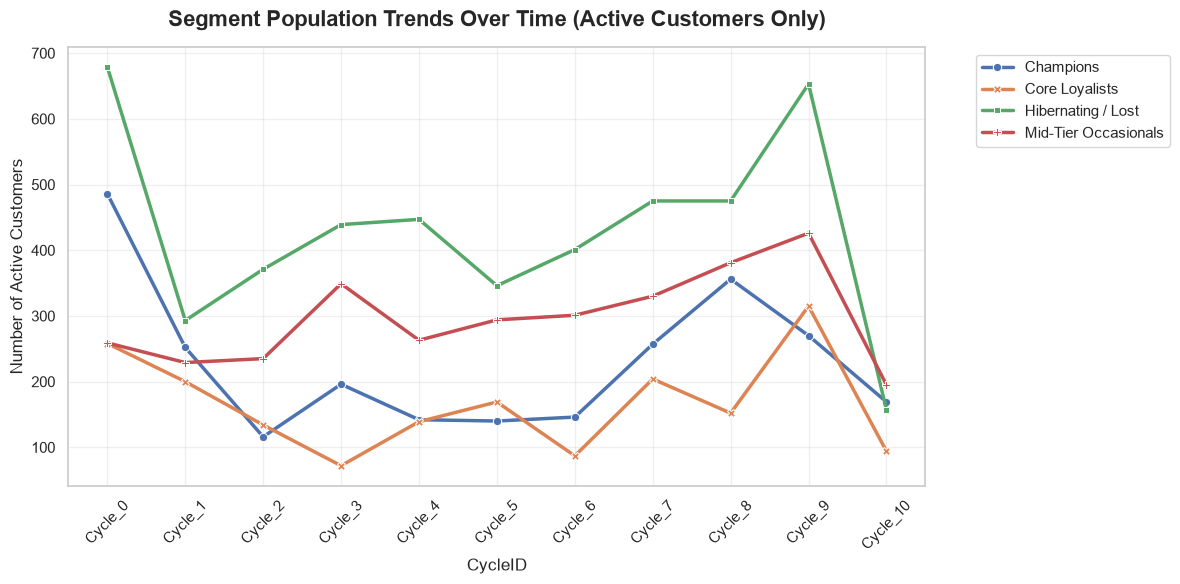


SUCCESS: All Transitions logged to database! Visualizations generated.


In [28]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from math import pi
import warnings

# Bypass Jupyter Notebook rendering issues for interactive plots
pio.renderers.default = 'browser'
warnings.filterwarnings('ignore')

print("--- PHASE 6B: TRANSITION ANALYTICS & DASHBOARDS ---")

# ==========================================
# 1. SETUP TRANSITION LEDGER
# ==========================================
def setup_transition_ledger():
    conn = sqlite3.connect('csrs_pipeline_b.db')
    cursor = conn.cursor()
    cursor.execute("DROP TABLE IF EXISTS Segment_Transitions")
    cursor.execute('''
    CREATE TABLE Segment_Transitions (
        Transition_ID INTEGER PRIMARY KEY AUTOINCREMENT,
        CustomerID TEXT,
        Start_Cycle TEXT,
        End_Cycle TEXT,
        Segment_Name_Start TEXT, -- FIX: Updated to match Pandas
        Segment_Name_End TEXT,   -- FIX: Updated to match Pandas
        Is_Migration INTEGER
    )
    ''')
    conn.commit()
    conn.close()

# ==========================================
# 2. CALCULATE FLOW BETWEEN ANY TWO CYCLES
# ==========================================
def compare_cycles_and_log(start_cycle, end_cycle):
    conn = sqlite3.connect('csrs_pipeline_b.db')
    
    # Pull Start Cycle (If Cycle 0, pull from baseline table, else dynamic table)
    if start_cycle == 'Cycle_0':
        df_start = pd.read_sql_query("SELECT CustomerID, Baseline_Segment_Name as Segment_Name FROM Time_Cycle_0_Segmentation", conn)
    else:
        df_start = pd.read_sql_query(f"SELECT CustomerID, Segment_Name FROM Dynamic_Segmentation_Results WHERE CycleID = '{start_cycle}'", conn)
        
    # Pull End Cycle
    df_end = pd.read_sql_query(f"SELECT CustomerID, Segment_Name FROM Dynamic_Segmentation_Results WHERE CycleID = '{end_cycle}'", conn)
    
    # Merge on CustomerID to see who moved where
    df_flow = pd.merge(df_start, df_end, on='CustomerID', how='inner', suffixes=('_Start', '_End'))
    df_flow['Start_Cycle'] = start_cycle
    df_flow['End_Cycle'] = end_cycle
    
    # Flag if they changed segments
    df_flow['Is_Migration'] = (df_flow['Segment_Name_Start'] != df_flow['Segment_Name_End']).astype(int)
    
    # Log to Database
    insert_cols = ['CustomerID', 'Start_Cycle', 'End_Cycle', 'Segment_Name_Start', 'Segment_Name_End', 'Is_Migration']
    df_flow[insert_cols].to_sql('Segment_Transitions', conn, if_exists='append', index=False)
    conn.close()
    
    return df_flow

# ==========================================
# 3. VISUAL 1: SANKEY DIAGRAM (MIGRATION FLOW)
# ==========================================
def plot_sankey_transitions(df_flow, title):
    # Group and count the transitions
    flow_counts = df_flow.groupby(['Segment_Name_Start', 'Segment_Name_End']).size().reset_index(name='Count')
    
    # Create unique integer IDs for every segment node
    all_nodes = list(pd.unique(flow_counts[['Segment_Name_Start', 'Segment_Name_End']].values.ravel('K')))
    node_mapping = {node: i for i, node in enumerate(all_nodes)}
    
    flow_counts['Start_ID'] = flow_counts['Segment_Name_Start'].map(node_mapping)
    flow_counts['End_ID'] = flow_counts['Segment_Name_End'].map(node_mapping)
    
    # Build Plotly Figure
    fig = go.Figure(data=[go.Sankey(
        node=dict(
          pad=20,
          thickness=20,
          line=dict(color="black", width=0.5),
          label=all_nodes,
          color="rgba(31, 119, 180, 0.8)"
        ),
        link=dict(
          source=flow_counts['Start_ID'], 
          target=flow_counts['End_ID'], 
          value=flow_counts['Count']
        )
    )])
    
    fig.update_layout(title_text=title, font_size=18, height=800)
    fig.write_html("visual_sankey_diagram.html") 
    fig.show() 

# ==========================================
# 4. VISUAL 2: LINE TREND CHART (FIXED SORTING)
# ==========================================
def plot_segment_trends():
    conn = sqlite3.connect('csrs_pipeline_b.db')
    c0 = pd.read_sql_query("SELECT 'Cycle_0' as CycleID, Baseline_Segment_Name as Segment_Name FROM Time_Cycle_0_Segmentation", conn)
    c_dyn = pd.read_sql_query("SELECT CycleID, Segment_Name FROM Dynamic_Segmentation_Results", conn)
    conn.close()
    
    df_all = pd.concat([c0, c_dyn])
    trend = df_all.groupby(['CycleID', 'Segment_Name']).size().unstack().fillna(0)
    
    # Strict chronological sorting bypasses the string "Cycle_10" alphabetically preceding "Cycle_2"
    trend.reset_index(inplace=True)
    trend['CycleNum'] = trend['CycleID'].str.extract(r'(\d+)').astype(int)
    trend.sort_values('CycleNum', inplace=True)
    trend.set_index('CycleID', inplace=True)
    trend.drop(columns=['CycleNum'], inplace=True)
    
    plt.figure(figsize=(12, 6), dpi=100)
    sns.lineplot(data=trend, markers=True, dashes=False, linewidth=2.5)
    plt.title('Segment Population Trends Over Time (Active Customers Only)', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Number of Active Customers')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('visual_trend_chart.png')
    plt.show()



# ==========================================
# EXECUTE FULL PIPELINE B DASHBOARD SUITE
# ==========================================
setup_transition_ledger()
flow_c0_c1 = compare_cycles_and_log('Cycle_0', 'Cycle_1')

print("Generating Dashboards...")

# 1. Generate Trend Line Plot
plot_segment_trends()

# 2. Generate Interactive Sankey Flow (Opens in Browser)
try:
    plot_sankey_transitions(flow_c0_c1, "Customer Migration Flow: Cycle 0 to Cycle 1")
except Exception as e:
    print(f"Sankey creation hit an error: {e}")




print("\nSUCCESS: All Transitions logged to database! Visualizations generated.")

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

def plot_segment_business_profiles(target_cycle='Cycle_9'):
    print(f"--- GENERATING BUSINESS PROFILES FOR {target_cycle.upper()} ---")
    conn = sqlite3.connect('csrs_pipeline_b.db')
    
    # 1. PULL RAW DATA
    if target_cycle == 'Cycle_0':
        query = f"""
        SELECT s.Baseline_Segment_Name as Segment_Name, p.Recency, p.Frequency, p.Monetary 
        FROM Time_Cycle_0_Segmentation s
        JOIN Data_Preprocessing_Results p ON s.CustomerID = p.CustomerID AND p.CycleID = 'Cycle_0'
        """
    else:
        query = f"""
        SELECT s.Segment_Name, p.Recency, p.Frequency, p.Monetary 
        FROM Dynamic_Segmentation_Results s
        JOIN Data_Preprocessing_Results p ON s.CustomerID = p.CustomerID AND s.CycleID = p.CycleID
        WHERE s.CycleID = '{target_cycle}'
        """
        
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    if df.empty:
        print(f"No data found for {target_cycle}. Please check the cycle name.")
        return

    # Set up styling
    sns.set_theme(style="whitegrid")
    segment_order = ['Champions', 'Core Loyalists', 'Mid-Tier Occasionals', 'Hibernating / Lost']
    # Filter to only include segments actually present in the data to avoid errors
    segment_order = [seg for seg in segment_order if seg in df['Segment_Name'].unique()]
    
    # ==========================================
    # PLOT 1: SEGMENT POPULATION SIZE (BAR CHART)
    # ==========================================
    plt.figure(figsize=(10, 5), dpi=100)
    ax = sns.countplot(data=df, x='Segment_Name', order=segment_order, palette='viridis')
    plt.title(f'Customer Headcount per Segment ({target_cycle})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Customer Segment')
    plt.ylabel('Number of Customers')
    
    # Add count labels on top of the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.savefig(f'visual_bar_headcount_{target_cycle}.png')
    plt.show()

    # ==========================================
    # PLOT 2: RFM AVERAGES PER SEGMENT (3 SUBPLOTS)
    # ==========================================
    # Calculate means
    rfm_means = df.groupby('Segment_Name')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=100)
    fig.suptitle(f'Average RFM Values by Segment ({target_cycle})', fontsize=16, fontweight='bold', y=1.05)
    
    # RECENCY (Lower is better)
    sns.barplot(data=rfm_means, x='Segment_Name', y='Recency', order=segment_order, ax=axes[0], palette='Blues_r')
    axes[0].set_title('Average Recency (Days Since Last Purchase)')
    axes[0].set_ylabel('Days')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=45)
    
    # FREQUENCY (Higher is better)
    sns.barplot(data=rfm_means, x='Segment_Name', y='Frequency', order=segment_order, ax=axes[1], palette='Greens')
    axes[1].set_title('Average Frequency (Total Purchases)')
    axes[1].set_ylabel('Purchases')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)
    
    # MONETARY (Higher is better)
    sns.barplot(data=rfm_means, x='Segment_Name', y='Monetary', order=segment_order, ax=axes[2], palette='Oranges')
    axes[2].set_title('Average Monetary (Total Revenue)')
    axes[2].set_ylabel('Revenue ($)')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'visual_bar_rfm_profiles_{target_cycle}.png')
    plt.show()

# Execute the function for Cycle 9 (Change this to any cycle you want to inspect!)
plot_segment_business_profiles(target_cycle='Cycle_9')

### customer visualization 

--- GENERATING BUSINESS PROFILES FOR CYCLE_9 ---


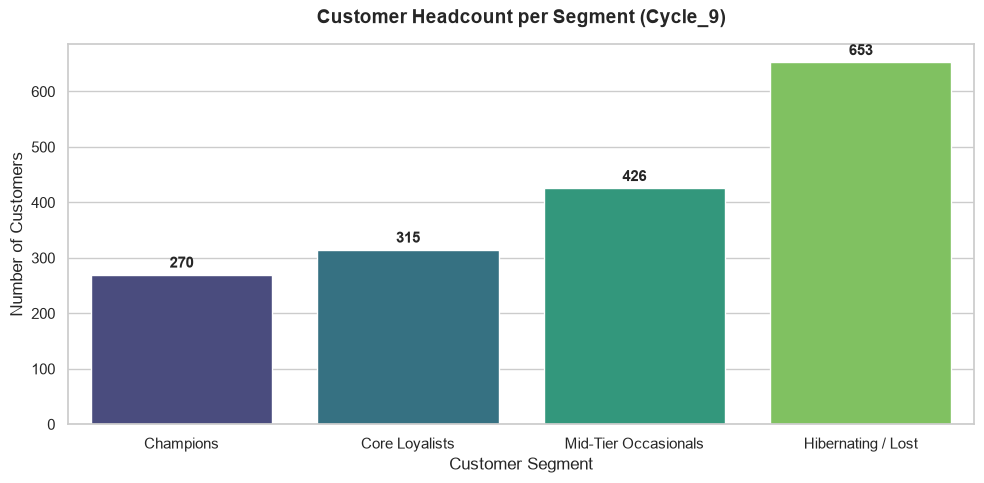

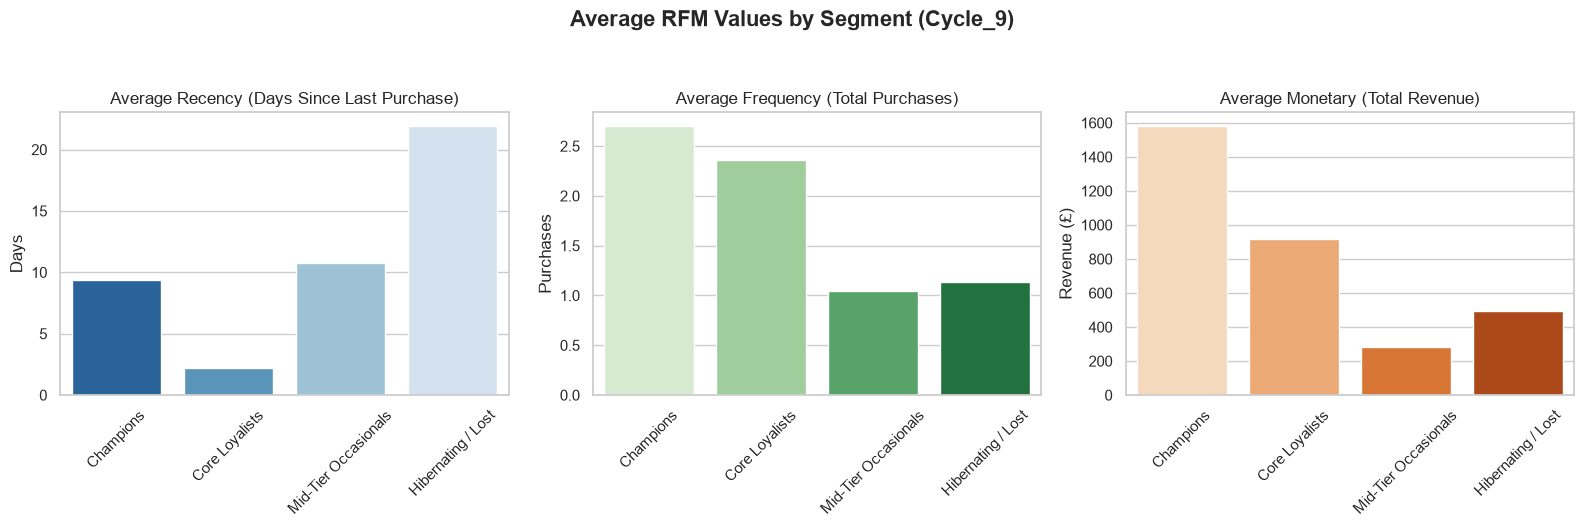

In [27]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

def plot_segment_business_profiles(target_cycle='Cycle_9'):
    print(f"--- GENERATING BUSINESS PROFILES FOR {target_cycle.upper()} ---")
    conn = sqlite3.connect('csrs_pipeline_b.db')
    
    # 1. PULL RAW DATA
    if target_cycle == 'Cycle_0':
        query = f"""
        SELECT s.Baseline_Segment_Name as Segment_Name, p.Recency, p.Frequency, p.Monetary 
        FROM Time_Cycle_0_Segmentation s
        JOIN Data_Preprocessing_Results p ON s.CustomerID = p.CustomerID AND p.CycleID = 'Cycle_0'
        """
    else:
        query = f"""
        SELECT s.Segment_Name, p.Recency, p.Frequency, p.Monetary 
        FROM Dynamic_Segmentation_Results s
        JOIN Data_Preprocessing_Results p ON s.CustomerID = p.CustomerID AND s.CycleID = p.CycleID
        WHERE s.CycleID = '{target_cycle}'
        """
        
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    if df.empty:
        print(f"No data found for {target_cycle}. Please check the cycle name.")
        return

    # Set up styling
    sns.set_theme(style="whitegrid")
    segment_order = ['Champions', 'Core Loyalists', 'Mid-Tier Occasionals', 'Hibernating / Lost']
    # Filter to only include segments actually present in the data to avoid errors
    segment_order = [seg for seg in segment_order if seg in df['Segment_Name'].unique()]
    
    # ==========================================
    # PLOT 1: SEGMENT POPULATION SIZE (BAR CHART)
    # ==========================================
    plt.figure(figsize=(10, 5), dpi=100)
    ax = sns.countplot(data=df, x='Segment_Name', order=segment_order, palette='viridis')
    plt.title(f'Customer Headcount per Segment ({target_cycle})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Customer Segment')
    plt.ylabel('Number of Customers')
    
    # Add count labels on top of the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.savefig(f'visual_bar_headcount_{target_cycle}.png')
    plt.show()

    # ==========================================
    # PLOT 2: RFM AVERAGES PER SEGMENT (3 SUBPLOTS)
    # ==========================================
    # Calculate means
    rfm_means = df.groupby('Segment_Name')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=100)
    fig.suptitle(f'Average RFM Values by Segment ({target_cycle})', fontsize=16, fontweight='bold', y=1.05)
    
    # RECENCY (Lower is better)
    sns.barplot(data=rfm_means, x='Segment_Name', y='Recency', order=segment_order, ax=axes[0], palette='Blues_r')
    axes[0].set_title('Average Recency (Days Since Last Purchase)')
    axes[0].set_ylabel('Days')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=45)
    
    # FREQUENCY (Higher is better)
    sns.barplot(data=rfm_means, x='Segment_Name', y='Frequency', order=segment_order, ax=axes[1], palette='Greens')
    axes[1].set_title('Average Frequency (Total Purchases)')
    axes[1].set_ylabel('Purchases')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)
    
   
    # MONETARY (Higher is better)
    sns.barplot(data=rfm_means, x='Segment_Name', y='Monetary', order=segment_order, ax=axes[2], palette='Oranges')
    axes[2].set_title('Average Monetary (Total Revenue)')
    
    # ---> UPDATE THIS LINE RIGHT HERE <---
    axes[2].set_ylabel('Revenue (£)') 
    
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'visual_bar_rfm_profiles_{target_cycle}.png')
    plt.show()

# Execute the function for Cycle 9 (Change this to any cycle you want to inspect!)
plot_segment_business_profiles(target_cycle='Cycle_9')

In [26]:
import sqlite3
import pandas as pd

print("--- INITIATING LABEL CORRECTION SCRIPT ---")
conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# We need to update both the Cycle 0 baseline table and the Dynamic tracking table
tables_to_update = [
    ('Time_Cycle_0_Segmentation', 'Baseline_Segment_Name'),
    ('Dynamic_Segmentation_Results', 'Segment_Name')
]

for table, col in tables_to_update:
    print(f"Correcting labels in {table}...")
    
    # 1. Temporarily rename to avoid overwriting each other during the swap
    cursor.execute(f"UPDATE {table} SET {col} = 'TEMP_CHAMP' WHERE {col} = 'Hibernating / Lost'")
    cursor.execute(f"UPDATE {table} SET {col} = 'TEMP_HIBE' WHERE {col} = 'Champions'")
    cursor.execute(f"UPDATE {table} SET {col} = 'TEMP_CORE' WHERE {col} = 'Mid-Tier Occasionals'")
    cursor.execute(f"UPDATE {table} SET {col} = 'TEMP_MID' WHERE {col} = 'Core Loyalists'")
    
    # 2. Finalize the correct mapping
    cursor.execute(f"UPDATE {table} SET {col} = 'Champions' WHERE {col} = 'TEMP_CHAMP'")
    cursor.execute(f"UPDATE {table} SET {col} = 'Hibernating / Lost' WHERE {col} = 'TEMP_HIBE'")
    cursor.execute(f"UPDATE {table} SET {col} = 'Core Loyalists' WHERE {col} = 'TEMP_CORE'")
    cursor.execute(f"UPDATE {table} SET {col} = 'Mid-Tier Occasionals' WHERE {col} = 'TEMP_MID'")

conn.commit()
conn.close()
print("SUCCESS: All database segment labels have been permanently corrected!")

--- INITIATING LABEL CORRECTION SCRIPT ---
Correcting labels in Time_Cycle_0_Segmentation...
Correcting labels in Dynamic_Segmentation_Results...
SUCCESS: All database segment labels have been permanently corrected!
